
# Enrich nbastatsv3 Shot Data (Full) — Improved Shot Clock + Hybrid Contest Classifier

This notebook loads your **`nbastatsv3_2024.csv`** play-by-play, then:
- Reconstructs an **approximate shot clock** per shot (`SHOT_CLOCK_APPROX`) using an improved possession reset model.
- Classifies field-goal shots into **likely_contested / borderline / likely_open** with a **hybrid** heuristic that uses
  **description + actionType + subType + distance + x/y** (NBA tenths-of-feet for corner-3) + late-clock.

It also includes helpers to:
- Enrich **one player in one game**
- Enrich **one player across all their games**
- Optionally export a **full-season** enriched shots CSV in batches


## ⏱️ Approximate Shot Clock (`SHOT_CLOCK_APPROX`)

### What it is

The **shot clock** is the 24-second timer (14 seconds on offensive rebounds) that governs how long a team has to attempt a shot. The official NBA public dataset (`nbastatsv3_2024.csv`) doesn’t include the actual shot clock value at the time of a shot.

So we **approximate** it by reconstructing possessions from play-by-play events:

1. **Reset events (new shot clock):**

   * **Made field goal** → opposing team inbounds, new 24s
   * **Turnover** → opposing team gains possession, new 24s
   * **Jump ball** → team that wins possession starts with 24s
   * **Defensive rebound** → new 24s
   * **Offensive rebound** → 14s reset (since 2018–19 rules)
   * **Defensive violations** (kicked ball, defensive 3-second, defensive goaltending) → 14s reset to offense
   * **Final free throws** (1 of 1, 2 of 2, 3 of 3, Technical/Flagrant/Clear Path last FT) → change of possession, new 24s

2. **Elapsed time since reset:**

   * We convert the `clock` field (`PT11M43.00S`) and `period` into **absolute game seconds**.
   * For each shot, we find the **last reset event in that period** and compute the difference in time.
   * This difference = **elapsed seconds since possession reset**.

3. **Shot clock approximation:**

   * `SHOT_CLOCK_APPROX = min(reset_value, time_since_reset)`
   * Where `reset_value` = 24 or 14 depending on event.
   * Example: If last reset was at 8:00 in the quarter, and the shot was at 7:50, then `time_since_reset = 10`, and the approximate shot clock is `24 – 10 = 14`.

⚠️ **Limitations:**

* Doesn’t model “minimum 14” exactly (e.g., when 18 seconds remain and a defensive kick-ball resets to 14, NBA rule keeps 18). We approximate as a hard reset to 14.
* Doesn’t track inbound delays or retained possession after technical/flagrant FTs.
* Still, it’s a solid proxy for distinguishing **early-clock shots (20+)** vs. **late-clock shots (≤5)**.

---

## 🏀 Contested/Open Heuristic (`contest_score`, `contest_label`, `contest_reasons`)

Since defender distance (`CLOSE_DEF_DIST`) isn’t in this dataset, we use **play-by-play text, action type, sub type, shot attributes, and coordinates** to *estimate* whether a shot was contested.

### How it works

1. **Action Type / SubType / Description**

   * **Contested-like** (+2): Pull-Up, Step Back, Fadeaway, Driving Layup, Driving Floating, Hook, Dunk, Putback, Alley-Oop, Reverse, Turnaround, etc.
   * **Open-like** (–1): Catch-and-Shoot, Spot Up, Generic Jump Shot, Regular.
   * **Description text** is also parsed to catch “step back”, “fadeaway”, “catch-and-shoot” even when subType is `Unknown`.

2. **Shot Location / Distance**

   * **At-rim / very close (≤5 ft)** (+1) → usually more defended.
   * **Mid-range (8–16 ft)** (+1) → often tightly contested.
   * **Deep above-the-break 3s (≥27 ft)** (–1) → more likely to be open.

3. **Corner vs Above-the-Break** (using NBA x/y coordinates, tenths of feet)

   * Corner-3 defined as **`|x| ≥ 220` and `y ≤ 50`**.
   * Corner catch-and-shoot or spot-up looks are nudged more open (–1).

4. **Shot Clock Context**

   * If `SHOT_CLOCK_APPROX ≤ 5` (+1): End-of-clock situations usually force **heavily contested or rushed** shots.

5. **Scoring System (`contest_score`):**

   * Start at 0
   * Add/subtract points from rules above
   * Examples:

     * Driving layup with 2 seconds left → +2 (driving) +1 (close range) +1 (late clock) = **+4**
     * Catch-and-shoot 28′ above-the-break three with 14 seconds left → –1 (catch-and-shoot) –1 (deep 3) = **–2**

6. **Labels (`contest_label`):**

   * `≥ 2` → **likely\_contested**
   * `= 1` → **borderline**
   * `≤ 0` → **likely\_open**

7. **Reasons (`contest_reasons`):**

   * Text log of why the shot got its score.
   * Example: `"subType: contested-like, distance: at-rim/very close, clock: late (<=5s)"`

---

## 🔎 Example from Jayson Tatum (gameId 22400001)

| Description                  | Shot Clock Approx | Contest Score | Contest Label     | Contest Reasons                                              |
| ---------------------------- | ----------------- | ------------- | ----------------- | ------------------------------------------------------------ |
| MISS 29′ Pullup 3            | 12                | +1            | borderline        | subType: contested-like, text: catch/spot                    |
| Driving Reverse Layup (made) | 0                 | +3            | likely\_contested | subType: contested-like, distance: at-rim/very close, clock… |
| Catch-and-shoot 27′ 3 (made) | 0                 | –1            | likely\_open      | subType: open-like, coords: corner-3, corner: catch/spot, …  |

---

✅ So in summary:

* **Approximate Shot Clock** = estimate of how much time was left on the shot clock when the shot was taken, reconstructed from possession resets (FGs, rebounds, TOs, FTs, violations).
* **Contested/Open Heuristic** = hybrid rule-based system that classifies shots into **likely\_open**, **borderline**, or **likely\_contested**, using **action type, subType, description text, shot distance, coordinates, and shot clock pressure**.


## 🏀 Court Coordinates & Zones (xLegacy / yLegacy)

### Our play-by-play uses **NBA shot coordinates in tenths of feet**:

- **xLegacy**: –250 to +250 (sideline ↔ sideline)  
- **yLegacy**: 0 to 470 (baseline → half-court)  
- **Basket**: (0, 0)

**Corner-3 rule used in the heuristic**: `|xLegacy| ≥ 220` **and** `yLegacy ≤ 50`  
All other 3PT shots are treated as **above-the-break**.

### Zones referenced by the heuristic

- **Paint (Key)**: roughly inside the lane (~0–15 ft) — typically tighter defense  
- **Mid-range**: ~8–16 ft annulus — often contested  
- **Corner-3 zone**: `|x|≥220 & y≤50` — catch-and-shoot here is often more open  
- **Above-the-break 3**: all other 3PTs; very deep (≥27 ft) are treated as more open

## 1. Setup

In [430]:

# If needed:
# !pip install pandas numpy matplotlib

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load Data

In [431]:

CSV_PATH = "raw_data/nbastatsv3_2024.csv"        # <- update if needed
all_data = pd.read_csv(CSV_PATH)
print("Loaded rows:", len(all_data))
display(all_data.head())


Loaded rows: 606538


,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,gameId
0,2,PT12M00.00S,1,0,NaN,0,NaN,NaN,0,0,...,0.0,0,NaN,Start of 1st Period (7:11 PM EST),period,start,0,0,1,22400001
1,4,PT12M00.00S,1,1610612738,BOS,201143,Horford,A. Horford,0,0,...,NaN,0,h,Jump Ball Horford vs. Capela: Tip to Wallace,Jump Ball,NaN,1,0,2,22400001
2,7,PT11M43.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-168,205,...,NaN,0,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,3,22400001
3,7,PT11M43.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,0,0,...,NaN,0,h,Tatum BLOCK (1 BLK),NaN,NaN,1,3,4,22400001
4,9,PT11M42.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,0,0,...,NaN,0,v,Risacher REBOUND (Off:1 Def:0),Rebound,Unknown,1,0,5,22400001


## 3. Improved Shot-Clock Reconstruction (v2)

In [432]:

REG_PERIOD_LEN = 12 * 60
OT_PERIOD_LEN  = 5 * 60

def _period_len_s(period:int)->int:
    return REG_PERIOD_LEN if period <= 4 else OT_PERIOD_LEN

def _abs_time(period:int, clock_iso:str)->int:
    # clock like 'PT11M43.00S'
    m = re.match(r"PT(\d+)M(\d+)\.\d+S", str(clock_iso))
    if not m:
        return None
    rem = int(m.group(1))*60 + int(m.group(2))
    return sum(_period_len_s(p) for p in range(1, period)) + (_period_len_s(period) - rem)

# Free-throw "final-of-sequence" subtypes that typically end a trip
_FINAL_FT = {
    "free throw 1 of 1", "free throw 2 of 2", "free throw 3 of 3",
    "free throw technical", "free throw technical 2 of 2",
    "free throw clear path 2 of 2",
    "free throw flagrant 1 of 1", "free throw flagrant 2 of 2", "free throw flagrant 3 of 3",
}

# Turnover subtypes to treat as possession change (24 reset to opponent)
_TURNOVER_POSSESSION = {
    "bad pass","lost ball","out of bounds - bad pass turnover","out of bounds lost ball turnover",
    "offensive foul turnover","offensive charge","shot clock turnover",
    "traveling","backcourt turnover","step out of bounds turnover",
    "double dribble","palming turnover","8 second violation","5 second violation",
    "illegal assist turnover","excess timeout turnover","basket from below turnover",
    "too many players turnover","punched ball turnover","inbound turnover","illegal screen turnover",
}

# Defensive violations that keep offense but reset to 14 (approx)
_DEFENSE_KEEPS_14 = {
    "kicked ball","kicked ball violation","defense 3 second","defensive goaltending"
}

def compute_shot_clock_v2(df: pd.DataFrame, game_id: int, player_id: int) -> pd.DataFrame:
    g = df[df["gameId"]==game_id].copy()
    g = g.sort_values(["period","actionNumber"]).reset_index(drop=True)

    # Absolute times
    g["ABS_TIME"] = g.apply(lambda r: _abs_time(int(r["period"]), r["clock"]), axis=1)

    resets = []  # (period, abs_time, reset_val, note)
    for _, ev in g.iterrows():
        per   = int(ev["period"])
        t     = ev["ABS_TIME"]
        aType = str(ev["actionType"]).strip().lower()
        sType = str(ev["subType"]).strip().lower()
        team  = ev.get("teamId", np.nan)

        # Jump ball (possession to winner -> 24)
        if aType == "jump ball":
            if pd.notna(team):
                resets.append((per,t,24,"jumpball"))
            continue

        # Rebounds
        if aType == "rebound":
            desc = str(ev.get("description","")).lower()
            is_off = ("off:" in desc) or ("offensive" in sType)
            if is_off:
                resets.append((per,t,14,"off_reb"))
            else:
                resets.append((per,t,24,"def_reb"))
            continue

        # Made / Missed shots
        if aType == "made shot":
            resets.append((per,t,24,"made_fg"))
            continue

        # Turnovers
        if aType == "turnover":
            if sType in _TURNOVER_POSSESSION or sType == "" or sType == "regular":
                resets.append((per,t,24,"turnover"))
            continue

        # Defensive violations -> 14 to offense
        if aType == "violation" and sType in _DEFENSE_KEEPS_14:
            resets.append((per,t,14,"def_violation_14"))
            continue

        # Free throws (end-of-trip approximations)
        if aType == "free throw":
            if sType in _FINAL_FT:
                resets.append((per,t,24,"final_ft"))
            continue

        # Period start: do nothing until control is established
        if aType == "period" and sType == "start":
            continue

    resets_df = pd.DataFrame(resets, columns=["PERIOD","ABS_TIME","RESET_VAL","RESET_NOTE"])

    # Player FG shots only
    shots = g[(g["personId"]==player_id) & (g["actionType"].str.contains("Shot", case=False, na=False))].copy()

    # Attach approx shot clock
    sc_vals, sc_notes = [], []
    for _, sh in shots.iterrows():
        per, t = int(sh["period"]), sh["ABS_TIME"]
        prior = resets_df[(resets_df["PERIOD"]==per) & (resets_df["ABS_TIME"]<=t)]
        if prior.empty:
            sc_vals.append(np.nan); sc_notes.append("no_reset_found")
        else:
            last = prior.iloc[-1]
            delta = max(0, t - int(last["ABS_TIME"]))
            cap   = int(last["RESET_VAL"])
            sc_vals.append(min(cap, delta))
            sc_notes.append(f"{last['RESET_NOTE']}({cap})")
    shots["SHOT_CLOCK_APPROX"] = sc_vals
    shots["SHOT_CLOCK_SOURCE"] = sc_notes
    return shots


## 4. Helpers — Parse Shot Attributes from description/actionType/subType

In [433]:
_SHOT_3PT_PAT = re.compile(
    r"\b3\s*pt\b|\b3pt\b|\b3-?point\b|\b3 pointer\b|\bthree point\b",
    re.IGNORECASE
)
_SHOT_2PT_PAT = re.compile(
    r"\b2\s*pt\b|\b2pt\b|\b2-?point\b|\b2 pointer\b",
    re.IGNORECASE
)
_FT_PAT = re.compile(r"\bfree throw\b", re.IGNORECASE)

def infer_shot_value_from_text(description:str, action_type:str, sub_type:str):
    """Return (shot_value, is_field_goal, is_free_throw) using text only."""
    d = (description or "")
    a = (action_type or "")
    s = (sub_type or "")
    text = f"{d} {a} {s}".lower()

    if _FT_PAT.search(text):
        return (1, False, True)

    if _SHOT_3PT_PAT.search(text):
        return (3, True, False)

    if _SHOT_2PT_PAT.search(text):
        return (2, True, False)

    # Generic FG cues default to 2
    fg_cues = (
        "made shot","missed shot","layup","dunk",
        "jumper","jump shot","hook","putback","tip","bank","fadeaway"
    )
    if any(cue in text for cue in fg_cues):
        return (2, True, False)

    return (np.nan, False, False)


## 5. Contest Classifier v3 — description + actionType + subType + coords + distance

In [434]:

def classify_contest_level_v3(df: pd.DataFrame) -> pd.DataFrame:
    """
    Contest labeling that considers:
      - description, actionType, subType (to infer semantics and 2PT/3PT/FT)
      - shotDistance (or SHOT_DISTANCE) if present
      - xLegacy/yLegacy for corner-3 vs above-the-break (tenths of feet; abs(x)>=220 & y<=50 -> corner)
      - SHOT_CLOCK_APPROX for late-clock pressure
    """
    def nstr(x): return (str(x).strip().lower()) if pd.notna(x) else ""

    contested_like = {
        "pullup jump shot","running pull-up jump shot",
        "step back jump shot","turnaround fadeaway shot","fadeaway jump shot",
        "driving floating jump shot","floating jump shot","driving floating bank jump shot",
        "driving reverse layup shot","reverse layup shot",
        "driving layup shot","running layup shot","tip layup shot","putback layup shot",
        "driving dunk shot","running dunk shot","tip dunk shot","putback dunk shot","alley oop dunk shot","alley oop layup shot",
        "turnaround hook shot","driving hook shot","hook shot","hook bank shot",
        "turnaround bank hook shot","turnaround fadeaway bank jump shot","fadeaway bank shot","turnaround bank shot","jump bank shot"
    }
    open_like = {"jump shot","running jump shot","spot up","catch and shoot","catch-and-shoot","regular"}

    xcol, ycol = "xLegacy", "yLegacy"
    has_coords = (xcol in df.columns) and (ycol in df.columns)

    out_rows = []
    for _, r in df.iterrows():
        desc = nstr(r.get("description"))
        a    = nstr(r.get("actionType"))
        s    = nstr(r.get("subType"))

        shotv = r.get("shotValue", np.nan)
        if pd.isna(shotv):
            shotv, is_fg, is_ft = infer_shot_value_from_text(r.get("description",""), r.get("actionType",""), r.get("subType",""))
        else:
            is_fg, is_ft = True, False


        # Free throws: not labeled for contest
        if is_ft:
            new = r.copy()
            new["contest_score"] = np.nan
            new["contest_label"] = "n/a_free_throw"
            new["contest_reasons"] = "free throw"
            out_rows.append(new)
            continue

        if not is_fg:
            new = r.copy()
            new["contest_score"] = np.nan
            new["contest_label"] = "n/a_non_fg"
            new["contest_reasons"] = "not a field goal"
            out_rows.append(new)
            continue

        # Distance
        dist = r.get("shotDistance", r.get("SHOT_DISTANCE", np.nan))
        try: dist = float(dist) if pd.notna(dist) else np.nan
        except: dist = np.nan

        # Coords
        try:
            rx = float(r.get(xcol)) if has_coords else np.nan
            ry = float(r.get(ycol)) if has_coords else np.nan
        except:
            rx, ry = np.nan, np.nan

        is_3 = (shotv == 3)
        is_corner = bool(is_3 and pd.notna(rx) and pd.notna(ry) and (abs(rx) >= 220) and (ry <= 50))
        is_above_break = bool(is_3 and (not is_corner))

        score = 0
        why = []

        # 1) subType signals
        if s in contested_like:
            score += 2; why.append("subType: contested-like")
        if s in open_like:
            score -= 1; why.append("subType: open-like")

        # 2) text cues as backup for Unknown subType
        text = f"{desc} {a}".lower()
        if ("step back" in text) or ("pull-up" in text) or ("pullup" in text) or ("fadeaway" in text):
            score += 1; why.append("text: pressure-move")
        if ("catch and shoot" in text) or ("catch-and-shoot" in text) or ("spot up" in text) or ("spot-up" in text):
            score -= 1; why.append("text: catch/spot")

        # 3) distance nudges
        if pd.notna(dist):
            if dist <= 5:
                score += 1; why.append("distance: at-rim/very close")
            if 8 <= dist <= 16:
                score += 1; why.append("distance: mid-range")
            if is_above_break and dist >= 27:
                score -= 1; why.append("distance: deep above-break 3 (>=27ft)")

        # 4) corner nuance
        if is_corner:
            why.append("coords: corner-3")
            if ("catch and shoot" in text) or ("catch-and-shoot" in text) or ("spot up" in text) or ("spot-up" in text) or (s in {"jump shot","spot up","catch and shoot","catch-and-shoot"}):
                score -= 1; why.append("corner: catch/spot")

        # 5) late-clock
        sc = r.get("SHOT_CLOCK_APPROX", np.nan)
        try: sc = float(sc) if pd.notna(sc) else np.nan
        except: sc = np.nan
        if pd.notna(sc) and sc <= 5:
            score += 1; why.append("clock: late (<=5s)")

        # 6) label
        if score >= 2: label = "likely_contested"
        elif score == 1: label = "borderline"
        else: label = "likely_open"

        new = r.copy()
        new["shotValue"] = shotv
        new["contest_score"] = score
        new["contest_label"] = label
        new["contest_reasons"] = ", ".join(why)
        out_rows.append(new)

    return pd.DataFrame(out_rows).reset_index(drop=True)


## 6. Enrichment Helpers (one game, one player / all games)

In [435]:

def enrich_player_game_v2(df: pd.DataFrame, game_id: int, player_id: int) -> pd.DataFrame:
    shots = compute_shot_clock_v2(df, game_id=game_id, player_id=player_id)
    return classify_contest_level_v3(shots)

def enrich_player_all_games_v2(df: pd.DataFrame, player_id: int, game_ids=None) -> pd.DataFrame:
    player_events = df[df["personId"]==player_id]
    all_gids = sorted(player_events["gameId"].unique())
    if game_ids is None:
        game_ids = all_gids
    else:
        game_ids = [gid for gid in game_ids if gid in all_gids]

    enriched = []
    for gid in game_ids:
        shots = enrich_player_game_v2(df, gid, player_id)
        if not shots.empty:
            enriched.append(shots)
    return pd.concat(enriched, ignore_index=True) if enriched else pd.DataFrame()


## 7. Example — All games for Steph Curry (201939)

Total Curry shots: 1258


,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,videoAvailable,shotValue,actionId,gameId,ABS_TIME,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons
0,12,PT11M28.00S,1,1610612744,GSW,201939,Curry,S. Curry,-199,157,...,1,3,6,22400007,32,0.0,made_fg(24),0,likely_open,"subType: open-like, clock: late (<=5s)"
1,37,PT09M14.00S,1,1610612744,GSW,201939,Curry,S. Curry,-34,15,...,1,2,25,22400007,166,0.0,made_fg(24),2,likely_contested,"distance: at-rim/very close, clock: late (<=5s)"
2,42,PT09M00.00S,1,1610612744,GSW,201939,Curry,S. Curry,179,237,...,1,3,29,22400007,180,4.0,off_reb(14),3,likely_contested,"subType: contested-like, text: pressure-move, ..."
3,94,PT06M22.00S,1,1610612744,GSW,201939,Curry,S. Curry,-175,264,...,1,3,68,22400007,338,0.0,made_fg(24),3,likely_contested,"subType: contested-like, text: pressure-move, ..."
4,121,PT04M26.00S,1,1610612744,GSW,201939,Curry,S. Curry,137,36,...,1,2,87,22400007,454,14.0,off_reb(14),4,likely_contested,"subType: contested-like, text: pressure-move, ..."
5,128,PT04M07.00S,1,1610612744,GSW,201939,Curry,S. Curry,161,120,...,1,2,95,22400007,473,14.0,off_reb(14),3,likely_contested,"subType: contested-like, text: pressure-move"
6,133,PT03M33.00S,1,1610612744,GSW,201939,Curry,S. Curry,-20,2,...,1,2,102,22400007,507,14.0,off_reb(14),3,likely_contested,"subType: contested-like, distance: at-rim/very..."
7,148,PT02M14.00S,1,1610612744,GSW,201939,Curry,S. Curry,-25,183,...,1,2,114,22400007,586,14.0,off_reb(14),3,likely_contested,"subType: contested-like, text: pressure-move"
8,295,PT04M18.00S,2,1610612744,GSW,201939,Curry,S. Curry,129,252,...,1,3,215,22400007,1182,21.0,made_fg(24),2,likely_contested,"subType: contested-like, text: pressure-move, ..."
9,347,PT00M08.10S,2,1610612744,GSW,201939,Curry,S. Curry,5,71,...,1,2,252,22400007,1432,0.0,final_ft(24),3,likely_contested,"subType: contested-like, clock: late (<=5s)"


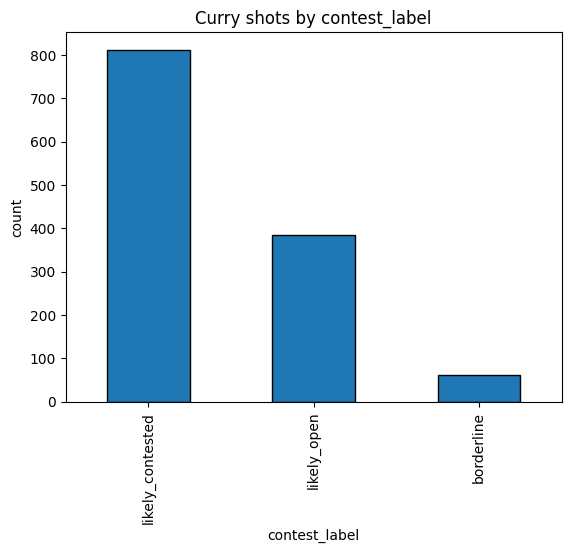

In [436]:

curry_all = enrich_player_all_games_v2(all_data, player_id=201939)
print("Total Curry shots:", len(curry_all))
display(curry_all.head(10))

# Simple plots (one figure each)
plt.figure()
curry_all["contest_label"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Curry shots by contest_label")
plt.xlabel("contest_label"); plt.ylabel("count")
plt.show()

# Save to CSV
output_file = "nbastatsv3_2024_steph_curry_shots.csv"
curry_all.to_csv(output_file, index=False)


## 8. Full-season export (all shots for all players, batched)

In [437]:

OUTPUT_CSV = "enriched_data/nbastatsv3_2024_enriched_shots.csv"

# Shot events only to reduce pairs
season_shots = all_data[all_data["actionType"].str.contains("Shot", case=False, na=False)].copy()

# Unique (gameId, personId) pairs
pairs = season_shots[["gameId","personId"]].drop_duplicates().values.tolist()

batch = []
written_any = False
for i, (gid, pid) in enumerate(pairs, 1):
    enriched = enrich_player_game_v2(all_data, game_id=gid, player_id=pid)
    if not enriched.empty:
        batch.append(enriched)
    # write every 50
    if i % 50 == 0:
        nonempty = [b for b in batch if (b is not None and not b.empty)]
        if nonempty:
            pd.concat(nonempty, ignore_index=True).to_csv(
                OUTPUT_CSV, mode=("w" if not written_any else "a"),
                header=(not written_any), index=False
            )
            written_any = True
        batch = []
        print(f"Processed {i}/{len(pairs)} pairs...")

# Flush remainder
nonempty = [b for b in batch if (b is not None and not b.empty)]
if nonempty:
    pd.concat(nonempty, ignore_index=True).to_csv(
        OUTPUT_CSV, mode=("w" if not written_any else "a"),
        header=(not written_any), index=False
    )
    written_any = True

print("Saved:", OUTPUT_CSV)


Processed 50/24835 pairs...
Processed 100/24835 pairs...
Processed 150/24835 pairs...
Processed 200/24835 pairs...
Processed 250/24835 pairs...
Processed 300/24835 pairs...
Processed 350/24835 pairs...
Processed 400/24835 pairs...
Processed 450/24835 pairs...
Processed 500/24835 pairs...
Processed 550/24835 pairs...
Processed 600/24835 pairs...
Processed 650/24835 pairs...
Processed 700/24835 pairs...
Processed 750/24835 pairs...
Processed 800/24835 pairs...
Processed 850/24835 pairs...
Processed 900/24835 pairs...
Processed 950/24835 pairs...
Processed 1000/24835 pairs...
Processed 1050/24835 pairs...
Processed 1100/24835 pairs...
Processed 1150/24835 pairs...
Processed 1200/24835 pairs...
Processed 1250/24835 pairs...
Processed 1300/24835 pairs...
Processed 1350/24835 pairs...
Processed 1400/24835 pairs...
Processed 1450/24835 pairs...
Processed 1500/24835 pairs...
Processed 1550/24835 pairs...
Processed 1600/24835 pairs...
Processed 1650/24835 pairs...
Processed 1700/24835 pairs...


## 9. Sanity Check - GSW Total Points
Compare GSW field-goal points with https://www.basketball-reference.com/teams/GSW/2025.html#all_totals_stats (Update if needed)

In [438]:
import pandas as pd
import re

ENRICHED_CSV = "enriched_data/nbastatsv3_2024_enriched_shots.csv"
GSW_ID = 1610612744  # Golden State Warriors

def load_enriched_clean(path: str) -> pd.DataFrame:
    # 1) Read as strings to avoid parse errors
    df = pd.read_csv(
        path,
        dtype=str,
        low_memory=False,
        on_bad_lines="skip",      # remove if your pandas is older
        encoding_errors="ignore"
    )

    # 2) Strip whitespace across object columns
    df = df.apply(lambda s: s.str.strip() if s.dtype == "object" else s)

    # 3) Drop repeated header rows appearing mid-file
    key_cols = [c for c in ["teamId", "gameId", "shotResult", "shotValue", "isFieldGoal", "actionId"] if c in df.columns]
    if key_cols:
        mask = pd.Series(False, index=df.index)
        for c in key_cols:
            mask = mask | df[c].eq(c)
        df = df[~mask]

    # 4) Normalize casing and types
    if "shotResult" in df.columns:
        df["shotResult"] = df["shotResult"].str.upper()

    for col in ["teamId", "isFieldGoal", "shotValue"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 5) **Normalize gameId** to NBA 10-digit format (e.g., 0022000001)
    #    - extract digits
    #    - zero-pad to length 10
    if "gameId" in df.columns:
        digits = df["gameId"].astype(str).str.extract(r"(\d+)", expand=False)
        df["gameId_norm"] = digits.fillna("").apply(lambda x: x.zfill(10) if x else x)
        # keep rows that have a normalized gameId
        df = df[df["gameId_norm"] != ""]
    else:
        df["gameId_norm"] = pd.NA  # fallback

    # 6) Keep rows with necessary fields
    df = df.dropna(subset=[c for c in ["teamId", "shotResult", "gameId_norm"] if c in df.columns])

    # 7) Deduplicate events (same game & action & team)
    if all(c in df.columns for c in ["gameId_norm", "actionId", "teamId"]):
        df = df.drop_duplicates(subset=["gameId_norm", "actionId", "teamId"])

    # 8) Restrict to **regular season** games only: gameId starts with "002"
    df = df[df["gameId_norm"].str.startswith("002")]

    # 9) Use pandas nullable integers
    for col in ["teamId", "isFieldGoal", "shotValue"]:
        if col in df.columns:
            df[col] = df[col].astype("Int64")

    return df

# --- Load & compute ---
season_enriched = load_enriched_clean(ENRICHED_CSV)
gsw = season_enriched[season_enriched["teamId"] == GSW_ID]

# Made field goals
gsw_fg_made = gsw[(gsw["isFieldGoal"] == 1) & (gsw["shotResult"] == "MADE")]

fgm = len(gsw_fg_made)
fg3m = (gsw_fg_made["shotValue"] == 3).sum()
fg2m = fgm - fg3m
pts = 2 * fg2m + 3 * fg3m

print("GSW regular-season field-goal totals (after clean + dedupe + ID normalization):")
print(f"PTS: {pts} | FGM: {fgm} | FG3M: {fg3m} | FG2M: {fg2m}")

# Diagnostics
prefix_counts = (season_enriched.assign(prefix=season_enriched["gameId_norm"].str[:3])
                 .groupby("prefix").size())
print("\nRows by normalized gameId prefix:")
print(prefix_counts)

print("\nSample normalized gameIds (first 10):")
print(season_enriched["gameId_norm"].drop_duplicates().head(10).to_list())

GSW regular-season field-goal totals (after clean + dedupe + ID normalization):
PTS: 7948 | FGM: 3342 | FG3M: 1264 | FG2M: 2078

Rows by normalized gameId prefix:
prefix
002    219528
dtype: int64

Sample normalized gameIds (first 10):
['0022400001', '0022400002', '0022400003', '0022400004', '0022400005', '0022400006', '0022400007', '0022400008', '0022400009', '0022400010']


## 10. Sanity Check — Missing `shotValue`

In [439]:

missing = season_shots[(season_shots["actionType"].str.contains("Shot", case=False, na=False)) &
                      (season_shots["isFieldGoal"]==1)]
# Join with enriched data if available
try:
    enriched = pd.read_csv(OUTPUT_CSV)
    missing_sv = enriched[(enriched["isFieldGoal"]==1) & (enriched["shotValue"].isna())]
    print("Total FGs:", len(enriched[enriched["isFieldGoal"]==1]))
    print("FGs missing shotValue:", len(missing_sv))
    display(missing_sv.head())
except Exception as e:
    print("Could not run sanity check:", e)

Total FGs: 219528
FGs missing shotValue: 0


,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,videoAvailable,shotValue,actionId,gameId,ABS_TIME,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons


## 11. Sanity Check - GSW 3PA and 2PA

In [440]:
# Load the CSV file
df = pd.read_csv("enriched_data/nbastatsv3_2024_enriched_shots.csv")
df=df[df["teamId"] == 1610612744]

# gsw = season_enriched[season_enriched["teamId"] == GSW_ID]

# Get unique values with counts
shotValue_counts = df["shotValue"].value_counts().reset_index()
shotValue_counts.columns = ["shotValue", "count"]

shotValue_counts

,shotValue,count
0,2,3937
1,3,3475
